## MODELO PREDICCIÓN: GRU
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE


In [10]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from itertools import product
import pywt

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
agg_10_minutes_filtrado_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [11]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_filtrado_path, os.listdir(agg_10_minutes_filtrado_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [12]:
# ELECCIÓN DE VARIABLE
variable = "n_packets"

In [13]:
# INSTITUCIONES DISPONIBLES
# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Lista para ir acumulando los dataframes procesados
dfs_companded = []

# Recorrer todos los CSV de la carpeta
for file in sorted(os.listdir(agg_10_minutes_filtrado_path)):
    if file.endswith(".csv"):
        
        fpath = os.path.join(agg_10_minutes_filtrado_path, file)
        
        # Leer CSV
        df = pd.read_csv(fpath)
        
        # Comprobar que la variable existe
        if variable not in df.columns:
            raise ValueError(f"La variable '{variable}' no existe en {file}")
        
        # Merge para sustituir id_time por time
        df = (
            df.merge(times_df, on="id_time", how="left")
              .drop(columns=["id_time"])
        )
        
        # Renombrar la columna como variable_institucion
        institucion = file.replace(".csv", "")
        new_col = f"{variable}_{institucion}"
        
        df = df[["time", variable]].rename(columns={variable: new_col})
        
        # Convertir time a datetime y eliminar zona horaria
        df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
        
        # COMPANDING
        df_companded = aplicar_mu_law(df)
        
        # Reordenar columnas (time primero)
        cols = ['time'] + [c for c in df_companded.columns if c != 'time']
        df_companded = df_companded[cols]
        
        dfs_companded.append(df_companded)

# Unir todos por la columna 'time'
from functools import reduce

df_TS24_companded = reduce(
    lambda left, right: pd.merge(left, right, on="time", how="outer"),
    dfs_companded
)

# Ordenar por tiempo
df_TS24_companded = df_TS24_companded.sort_values("time").reset_index(drop=True)

df_TS24_companded


,time,n_packets_0,n_packets_10,n_packets_108,n_packets_109,n_packets_113,n_packets_139,n_packets_145,n_packets_147,n_packets_161,...,n_packets_56,n_packets_57,n_packets_59,n_packets_62,n_packets_68,n_packets_69,n_packets_70,n_packets_80,n_packets_86,n_packets_93
0,2023-10-09 00:03:49,0.556011,0.308059,0.320938,0.436240,0.483470,0.028138,0.053862,0.011124,0.046420,...,0.350974,0.300686,0.289392,0.012802,0.365583,0.375635,0.032108,0.366409,0.143416,0.046948
1,2023-10-09 00:13:49,0.612719,0.139530,0.331892,0.353694,0.419183,0.209788,0.039296,0.031258,0.046985,...,0.266701,0.276901,0.305307,0.011221,0.513558,0.226597,0.049837,0.349239,0.175270,0.053418
2,2023-10-09 00:23:49,0.529257,0.164183,0.331369,0.408780,0.598810,0.028003,0.043695,0.013011,0.054506,...,0.321299,0.271488,0.295524,0.015232,0.286149,0.290228,0.019230,0.245545,0.112729,0.042443
3,2023-10-09 00:33:49,0.545362,0.095732,0.291178,0.405769,0.500413,0.026490,0.052158,0.011774,0.086026,...,0.295125,0.329172,0.298182,0.011511,0.315418,0.139137,0.046266,0.345947,0.180590,0.049438
4,2023-10-09 00:43:49,0.550940,0.127565,0.433107,0.421811,0.557780,NaN,0.116546,0.032312,0.106470,...,0.222086,0.331067,0.326017,0.012131,0.389620,0.179745,0.037714,0.413748,0.264052,0.054488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.665485,0.200044,0.461846,0.400540,0.380357,0.008315,0.119590,0.009036,0.089353,...,0.194255,0.343790,0.414215,0.024924,0.514114,0.248525,0.010433,0.494226,0.124322,0.039821
40294,2024-07-14 21:20:52,0.689312,0.164220,0.499865,0.396086,0.399295,0.006449,0.104549,0.007381,0.068348,...,0.279120,0.362446,0.317204,0.028088,0.377748,0.216633,0.117986,0.417027,0.364026,0.159904
40295,2024-07-14 21:30:52,0.732208,0.234784,0.442110,0.409848,0.444484,NaN,0.129387,0.005440,0.071905,...,0.252054,0.366446,0.393873,0.027207,0.341581,0.152202,0.005644,0.635731,0.158493,0.036476
40296,2024-07-14 21:40:52,0.653425,0.206730,0.514592,0.384495,0.435723,NaN,0.111082,0.008739,0.080957,...,0.225311,0.312003,0.350342,0.025688,0.335605,0.222211,0.004297,0.473662,0.272068,0.135214


SEMANAS TOTALES: 32 

Comienza desde Semana 49, 2023 = lunes, 4 de diciembre ---> domingo, 10 de diciembre de 2023

Debido al comportamiento anomalo del principio del dataset. 

In [14]:
# DF CON TODAS LAS SEMANAS DE TODOS LOS FICHEROS
# -----------------------------------
# SEPARAR DF EN SEMANAS (una vez)
# -----------------------------------

iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

# Columnas reales (excluyendo auxiliares)
data_columns = [
    c for c in df_TS24_companded.columns 
    if c not in ['time', 'iso_year', 'iso_week']
]

weekly_data = {}

# -----------------------------------
# PROCESAR TODAS LAS COLUMNAS
# -----------------------------------

for variable_col in data_columns:

    for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
        
        col_name = f"{variable_col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[variable_col].reset_index(drop=True)

# Crear único DataFrame final
df_weeks = pd.DataFrame(weekly_data)




import re

def keep_column(col):
    # Busca patrón: _<semana>_<año> al final
    match = re.search(r'_(\d{1,2})_(\d{4})$', col)
    if match:
        week = int(match.group(1))
        year = int(match.group(2))
        
        # Mantener solo si es >= semana 49 de 2023
        return (year > 2023) or (year == 2023 and week >= 49)
    
    # Si la columna no tiene fecha, la dejamos
    return True

df_weeks = df_weeks[[col for col in df_weeks.columns if keep_column(col)]]

df_weeks

,n_packets_0_49_2023,n_packets_0_50_2023,n_packets_0_51_2023,n_packets_0_52_2023,n_packets_0_01_2024,n_packets_0_02_2024,n_packets_0_03_2024,n_packets_0_04_2024,n_packets_0_05_2024,n_packets_0_06_2024,...,n_packets_93_19_2024,n_packets_93_20_2024,n_packets_93_21_2024,n_packets_93_22_2024,n_packets_93_23_2024,n_packets_93_24_2024,n_packets_93_25_2024,n_packets_93_26_2024,n_packets_93_27_2024,n_packets_93_28_2024
0,0.723969,0.725587,0.702604,0.629336,0.599773,0.595336,0.554228,0.530591,0.691167,0.633386,...,0.037337,0.054758,0.037113,0.019459,0.018985,0.033479,0.036993,0.031225,0.032347,0.025493
1,0.668322,0.695635,0.659520,0.694687,0.638043,0.592817,0.625738,0.459894,0.667583,0.649483,...,0.029590,0.069814,0.026614,0.022038,0.024402,0.066656,0.023971,0.034998,0.193903,0.023434
2,0.660500,0.689444,0.620074,0.583893,0.646308,0.602545,0.636503,0.497940,0.642675,0.613608,...,0.037451,0.057537,0.111421,0.022393,0.026887,0.031799,0.026487,0.040024,0.089308,0.023020
3,0.668982,0.685812,0.643900,0.542177,0.625789,0.584312,0.601348,0.527492,0.751679,0.605859,...,0.044825,0.040091,0.022604,0.027323,0.015969,0.075987,0.027021,0.038250,0.023255,0.019086
4,0.669047,0.715490,0.604988,0.610449,0.622142,0.571461,0.585818,0.444755,0.634255,0.620129,...,0.036735,0.044204,0.032411,0.026207,0.020222,0.030025,0.021070,0.037234,0.033747,0.022920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.752083,0.769259,0.693026,0.634121,0.717784,0.694909,0.637606,0.758113,0.739107,0.659039,...,0.059729,0.032117,0.017074,0.022865,0.028168,0.021976,0.031450,0.035704,0.026936,NaN
1004,0.781181,0.766703,0.648280,0.602286,0.688963,0.626773,0.588929,0.696254,0.726003,0.616601,...,0.053951,0.022399,0.013922,0.025040,0.030049,0.025536,0.040991,0.033992,0.037085,NaN
1005,0.732735,0.736264,0.669987,0.610378,0.632965,0.619601,0.505011,0.704002,0.743235,0.617732,...,0.051888,0.029900,0.019945,0.021895,0.026845,0.028595,0.036119,0.035687,0.022920,NaN
1006,0.718102,0.692986,0.676527,0.666777,0.598466,0.635378,0.556107,0.679608,0.689005,0.651049,...,0.046633,0.023403,0.021851,0.022050,0.031048,0.037720,0.046448,0.273371,0.027595,NaN


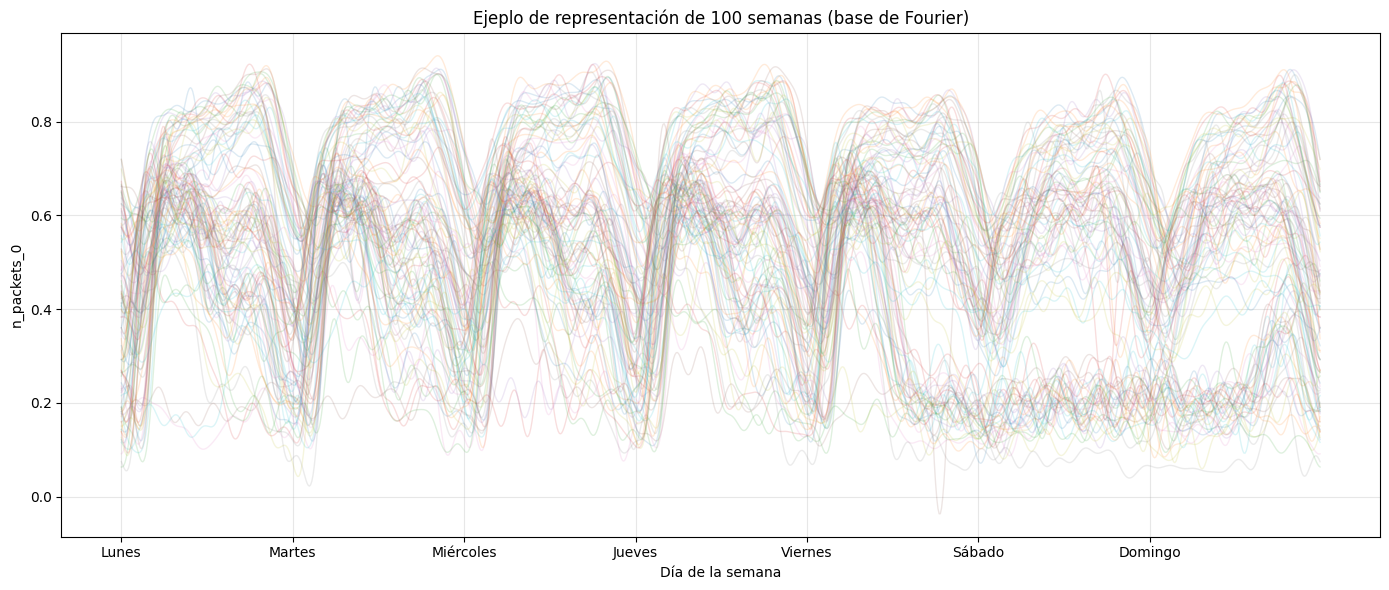

In [15]:
# PASAR DE DATOS ESCALARES A DATOS FUNCIONALES + REPRESENTACION
# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

# Convertir ±inf en NaN
df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)

# Eliminar columnas completamente vacías
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

# Interpolación temporal (por columnas = semanas)
df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

# Relleno de seguridad
df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DEFINIR DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]  # puntos temporales por semana

t = np.linspace(0, 1, n_time)  # dominio normalizado [0,1]

# ==========================================================
# 3️⃣ CREAR OBJETO FUNCIONAL
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,  # (n_semanas, n_time)
    grid_points=t
)

# ==========================================================
# 4️⃣ PROYECCIÓN A BASE DE FOURIER
# ==========================================================

n_basis = 99  # puedes ajustar

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

fd_fourier = fd.to_basis(basis)

# ==========================================================
# 5️⃣ EVALUAR FUNCIONES EN LA REJILLA
# ==========================================================

X = fd_fourier(t)  # evaluación
X = X.reshape(X.shape[0], -1)  # aseguramos shape (n_semanas, n_time)


# ==========================================================
# 6️⃣ REPRESENTACIÓN DE FUNCIONES (≥ 100)
# ==========================================================

# Número de funciones a representar
n_plot = min(100, X.shape[0])

# Eje temporal en horas (10 minutos por punto)
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # 0 → 168 horas

# Ticks diarios
days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)

plt.figure(figsize=(14, 6))

for i in range(n_plot):
    plt.plot(
        x_hours,
        X[i],
        alpha=0.15,
        linewidth=1
    )

plt.title(f"Ejeplo de representación de {n_plot} semanas (base de Fourier)")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [16]:
# DATAFRAME CON LOS COEF. DE LA BASE DE FOURIER
n_coef = fd_fourier.coefficients.shape[1]

coef_df = pd.DataFrame(
    fd_fourier.coefficients,
    index=df_weeks_clean.columns,
    columns=[f"coef_{i}" for i in range(n_coef)]
)

coef_df

,coef_0,coef_1,coef_2,coef_3,coef_4,coef_5,coef_6,coef_7,coef_8,coef_9,...,coef_89,coef_90,coef_91,coef_92,coef_93,coef_94,coef_95,coef_96,coef_97,coef_98
n_packets_0_49_2023,0.772245,0.008644,-0.009692,-0.006623,0.000538,-0.005755,0.011786,0.006268,0.002920,0.001313,...,-0.000369,-0.003896,-0.003407,-0.002097,-0.007065,0.001615,-0.002820,0.003887,0.000306,0.003965
n_packets_0_50_2023,0.783229,0.027851,-0.014720,-0.000467,-0.001945,0.002306,0.002980,0.001991,0.000256,0.001445,...,0.000556,0.001101,0.000169,-0.000968,-0.000428,-0.000605,0.000627,-0.000688,0.001093,0.003871
n_packets_0_51_2023,0.722688,0.058982,-0.021133,0.020784,0.008881,0.008845,-0.003395,0.013143,0.001110,0.015090,...,-0.001942,0.000950,-0.002626,-0.002328,0.000368,-0.000116,-0.000013,-0.000350,-0.001671,0.001356
n_packets_0_52_2023,0.624335,-0.002532,0.007234,0.005979,-0.006307,0.003203,-0.007220,0.002725,0.002772,0.002178,...,-0.002230,0.001543,0.002177,-0.000798,0.000238,0.001753,0.000385,0.000777,0.001835,0.001628
n_packets_0_01_2024,0.662838,0.012644,-0.012010,0.001644,-0.000908,-0.006820,0.001209,0.001303,-0.000863,-0.006809,...,0.001707,-0.000443,0.000898,0.001136,0.002296,-0.000418,0.001001,0.002028,0.000401,-0.001458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n_packets_93_24_2024,0.179484,0.058591,-0.020651,0.029994,0.021008,-0.003821,-0.002495,0.009120,0.009740,0.025344,...,0.002925,0.002153,-0.000074,0.001584,0.001531,0.004910,0.001996,0.008971,0.008779,-0.005089
n_packets_93_25_2024,0.166877,0.031292,-0.005063,0.035477,0.006453,0.024596,-0.012434,0.005107,0.028295,0.012233,...,0.002468,0.003072,0.000340,0.002182,0.001901,0.004356,0.001153,0.006149,0.008352,0.003105
n_packets_93_26_2024,0.145754,0.068224,0.024066,0.037121,0.002563,0.008767,-0.003134,0.008192,0.009834,0.018731,...,0.000818,-0.000963,-0.006667,-0.000410,0.000971,0.007067,0.002977,0.009370,0.013735,-0.005422
n_packets_93_27_2024,0.054838,0.004343,0.003255,0.001853,-0.000240,0.001716,0.001020,0.003520,0.000994,0.003364,...,-0.000197,0.001379,0.001026,0.000328,-0.001975,0.001285,-0.001189,0.000992,0.001382,0.003715


FORECASTING DE VARIABLES


data = 1427x31 = semanas x coeficientes

Epoch 0 | Train 0.415686 | Val 0.455263
Epoch 10 | Train 0.414948 | Val 0.452221
Epoch 20 | Train 0.360515 | Val 0.431180
Epoch 30 | Train 0.320581 | Val 0.413763
Epoch 40 | Train 0.302114 | Val 0.402056
Epoch 50 | Train 0.288669 | Val 0.397902
Epoch 60 | Train 0.280886 | Val 0.394993
Epoch 70 | Train 0.274098 | Val 0.392858
Epoch 80 | Train 0.263887 | Val 0.389849
Epoch 90 | Train 0.260754 | Val 0.390703
Epoch 100 | Train 0.258478 | Val 0.387859
Epoch 110 | Train 0.253222 | Val 0.392648
Epoch 120 | Train 0.250036 | Val 0.389120
Epoch 130 | Train 0.249547 | Val 0.393956
Early stopping
PDF guardado como: gru_attention_inst_0_week_20.pdf


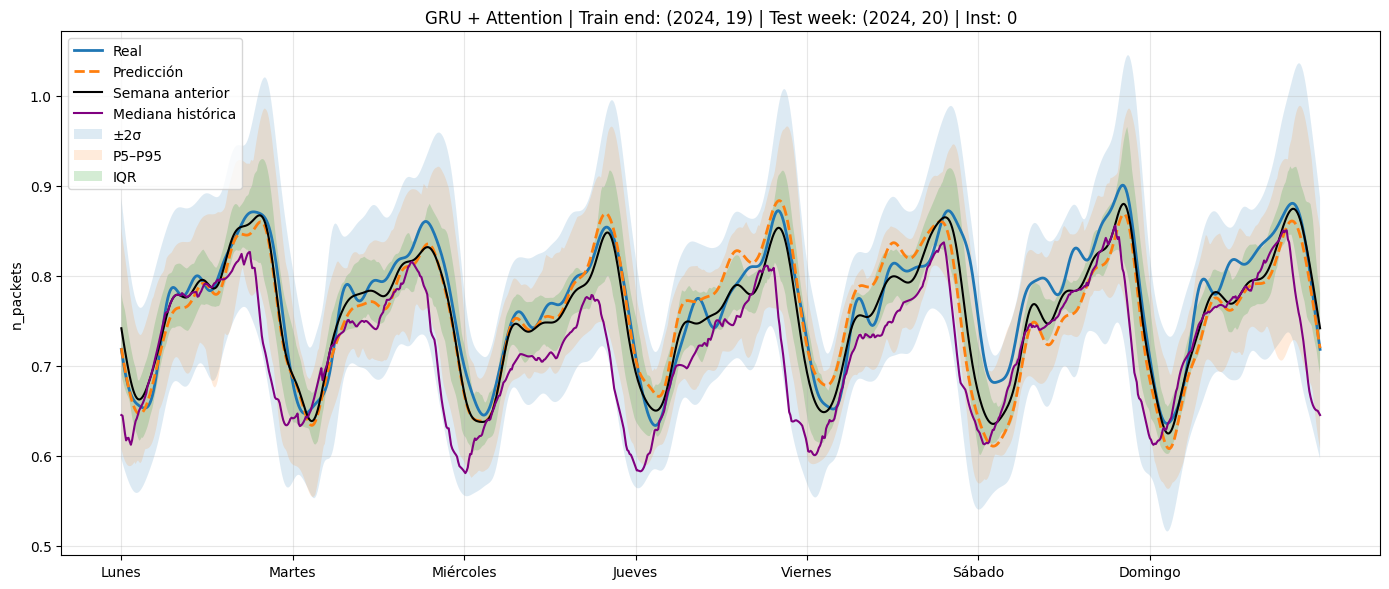


MÉTRICAS DE RECONSTRUCCIÓN

GRU + ATTENTION
MAE  : 0.0258
RMSE : 0.0338
R²   : 0.7482

SEMANA ANTERIOR
MAE  : 0.0180
RMSE : 0.0233
R²   : 0.8797

MEDIA HISTÓRICA
MAE  : 0.0521
RMSE : 0.0664
R²   : 0.0271

Tiempo ejecución: 26.79 segundos

Resumen:
            Modelo     MAE    RMSE      R2
0  GRU + Attention  0.0258  0.0338  0.7482
1  Semana anterior  0.0180  0.0233  0.8797
2  Media histórica  0.0521  0.0664  0.0271


In [17]:
# =========================
# WALK-FORWARD GRU MEJORADO v3 (CON BASELINES + BANDAS)
# =========================

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

# =========================
# CONFIG
# =========================

TARGET_INST = 0
TEST_WEEK = 20
TRAIN_END = "2024-W19"

window_size = 12
batch_size = 64

start_time = time.perf_counter()

# =========================
# 1. PARSE INDEX
# =========================

def parse_index(idx):
    match = re.match(r"n_packets_(\d+)_(\d+)_(\d+)", idx)
    inst, week, year = match.groups()
    return int(inst), int(year), int(week)

df = coef_df.copy()

df[['inst','year','week']] = df.index.to_series().apply(
    lambda x: pd.Series(parse_index(x))
)

df = df.sort_values(['inst','year','week'])

coef_cols = coef_df.columns

# =========================
# 2. FEATURES TEMPORALES
# =========================

df['day_of_week'] = df['week'] % 7
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# =========================
# 3. SPLIT TEMPORAL
# =========================

train_df = df[
    (df['year'] < 2024) |
    ((df['year'] == 2024) & (df['week'] <= TEST_WEEK - 1))
]

test_df = df[
    (df['inst'] == TARGET_INST) &
    (df['year'] == 2024) &
    (df['week'] == TEST_WEEK)
]

# =========================
# 4. SECUENCIAS
# =========================

scalers = {}

def create_sequences(df):
    X, y, inst_ids = [], [], []

    inst_list = sorted(df['inst'].unique())
    inst_to_idx = {inst:i for i,inst in enumerate(inst_list)}

    for inst in inst_list:
        df_inst = df[df['inst'] == inst].sort_values(['year','week'])

        values = df_inst[coef_cols].values

        # igual que LSTM
        values_no_dc = values[:, 1:]

        deltas = np.diff(values_no_dc, axis=0)

        scaler = StandardScaler()
        deltas_scaled = scaler.fit_transform(deltas)


        scalers[inst] = scaler

        for i in range(len(deltas_scaled) - window_size):
            X.append(deltas_scaled[i:i+window_size])
            y.append(deltas_scaled[i+window_size])
            inst_ids.append(inst_to_idx[inst])

    return np.array(X), np.array(y), np.array(inst_ids), inst_to_idx

X, y, inst_ids, inst_to_idx = create_sequences(train_df)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
inst_ids = torch.tensor(inst_ids, dtype=torch.long)

# =========================
# 5. SPLIT TRAIN / VAL
# =========================

cut = int(len(X) * 0.8)

X_train, X_val = X[:cut], X[cut:]
y_train, y_val = y[:cut], y[cut:]
inst_train, inst_val = inst_ids[:cut], inst_ids[cut:]

train_loader = DataLoader(
    TensorDataset(X_train, y_train, inst_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val, inst_val),
    batch_size=batch_size
)

# =========================
# 6. MODELO
# =========================

class GRUModel(nn.Module):
    def __init__(self, input_size, num_insts, hidden_size=128, emb_dim=16):
        super().__init__()

        self.embedding = nn.Embedding(num_insts, emb_dim)

        self.gru = nn.GRU(
            input_size + emb_dim,
            hidden_size,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.attn = nn.Linear(hidden_size, 1)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size + emb_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, input_size)
        )

    def forward(self, x, inst_id):

        emb = self.embedding(inst_id)
        emb_seq = emb.unsqueeze(1).repeat(1, x.size(1), 1)

        x = torch.cat([x, emb_seq], dim=2)

        out, _ = self.gru(x)

        weights = torch.softmax(self.attn(out), dim=1)
        out = torch.sum(weights * out, dim=1)

        out = torch.cat([out, emb], dim=1)

        return self.fc(out)

model = GRUModel(
    input_size=X.shape[2],
    num_insts=len(inst_to_idx)
)

# =========================
# 7. OPTIMIZACIÓN
# =========================

criterion = nn.SmoothL1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=15,
    factor=0.5
)

# =========================
# 8. TRAINING
# =========================

epochs = 200
patience = 30

best_loss = float('inf')
counter = 0

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb, instb in train_loader:
        optimizer.zero_grad()

        pred = model(xb, instb)
        loss = criterion(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb, instb in val_loader:
            pred = model(xb, instb)
            val_loss += criterion(pred, yb).item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter > patience:
        print("Early stopping")
        break

# =========================
# 9. PREDICCIÓN
# =========================

def predict(model, window, inst_tensor):
    model.eval()
    with torch.no_grad():
        return model(window, inst_tensor).cpu().numpy()

inst_idx = inst_to_idx[TARGET_INST]

df_inst = train_df[train_df['inst'] == TARGET_INST].sort_values(['year','week'])

values = df_inst[coef_cols].values

baseline = values[:, 0]
shape = values[:, 1:]

deltas = np.diff(shape, axis=0)

scaler = scalers[TARGET_INST]
deltas_scaled = scaler.transform(deltas)

last_window = torch.tensor(
    deltas_scaled[-window_size:],
    dtype=torch.float32
).unsqueeze(0)

inst_tensor = torch.tensor([inst_idx])

pred_scaled = predict(model, last_window, inst_tensor)[0]

pred_delta = scaler.inverse_transform(
    [pred_scaled]
)[0]

pred_shape = shape[-1] + pred_delta

pred_coef = np.concatenate([
    [baseline[-1]],
    pred_shape
])

real = test_df[coef_cols].values[0]

# =========================
# 10. RECONSTRUCCIÓN
# =========================

def reconstruct_signal_week(coefs, n_points):
    t = np.linspace(0, 2*np.pi, n_points)
    result = np.ones_like(t) * coefs[0]

    k = 1
    idx = 1

    while idx < len(coefs) - 1:
        a = coefs[idx]
        b = coefs[idx+1]

        result += a * np.cos(k*t) + b * np.sin(k*t)

        idx += 2
        k += 1

    return result

# =========================
# 11. SEÑALES
# =========================

n_time = int(7 * 24 * 60 / 10)
x_hours = np.arange(n_time) * 10 / 60

signal_real = reconstruct_signal_week(real, n_time)
signal_pred = reconstruct_signal_week(pred_coef, n_time)

# =========================
# 12. BASELINES HISTÓRICOS
# =========================

df_hist = train_df[
    train_df['inst'] == TARGET_INST
].sort_values(['year','week'])

baseline_matrix = []

for _, row in df_hist.iterrows():
    coefs = row[coef_cols].values
    signal = reconstruct_signal_week(coefs, n_time)
    baseline_matrix.append(signal)

baseline_matrix = np.array(baseline_matrix)

mean_t = baseline_matrix.mean(axis=0)
std_t = baseline_matrix.std(axis=0)
median_t = np.median(baseline_matrix, axis=0)

p5_t = np.percentile(baseline_matrix, 5, axis=0)
p95_t = np.percentile(baseline_matrix, 95, axis=0)

q1_t = np.percentile(baseline_matrix, 25, axis=0)
q3_t = np.percentile(baseline_matrix, 75, axis=0)

baseline_signal = baseline_matrix[-1]

# =========================
# 13. MÉTRICAS
# =========================

# -------------------------
# Predicción GRU
# -------------------------

mae_pred = mean_absolute_error(
    signal_real,
    signal_pred
)

rmse_pred = np.sqrt(
    mean_squared_error(
        signal_real,
        signal_pred
    )
)

r2_pred = r2_score(
    signal_real,
    signal_pred
)

# -------------------------
# Semana anterior
# -------------------------

mae_prev = mean_absolute_error(
    signal_real,
    baseline_signal
)

rmse_prev = np.sqrt(
    mean_squared_error(
        signal_real,
        baseline_signal
    )
)

r2_prev = r2_score(
    signal_real,
    baseline_signal
)

# -------------------------
# Media histórica
# -------------------------

mae_mean = mean_absolute_error(
    signal_real,
    mean_t
)

rmse_mean = np.sqrt(
    mean_squared_error(
        signal_real,
        mean_t
    )
)

r2_mean = r2_score(
    signal_real,
    mean_t
)

# =========================
# 14. PLOT FINAL
# =========================

plt.figure(figsize=(14,6))

plt.plot(x_hours, signal_real, label="Real", linewidth=2)
plt.plot(x_hours, signal_pred, '--', label="Predicción", linewidth=2)

plt.plot(x_hours, baseline_signal, label="Semana anterior", color='black')
plt.plot(x_hours, median_t, label="Mediana histórica", color='purple')

# bandas
plt.fill_between(
    x_hours,
    baseline_signal - 2*std_t,
    baseline_signal + 2*std_t,
    alpha=0.15,
    label='±2σ'
)

plt.fill_between(
    x_hours,
    baseline_signal + (p5_t - mean_t),
    baseline_signal + (p95_t - mean_t),
    alpha=0.15,
    label='P5–P95'
)

plt.fill_between(
    x_hours,
    baseline_signal + (q1_t - mean_t),
    baseline_signal + (q3_t - mean_t),
    alpha=0.2,
    label='IQR'
)

days = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
ticks = np.arange(0, 7*24, 24)

plt.xticks(ticks, days)

plt.title(
    f"GRU | Train end: {TRAIN_END} | "
    f"Test week: {TEST_WEEK} | Inst: {TARGET_INST}"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()




plt.title(
    f"GRU + Attention | Train end: (2024, 19) | "
    f"Test week: (2024, 20) | Inst: 0"
)

plt.grid(alpha=0.3)
plt.ylabel("n_packets")
plt.legend()
plt.tight_layout()

# =========================
# GUARDAR PDF
# =========================

pdf_name = (
    f"gru_attention_inst_{TARGET_INST}_"
    f"week_{TEST_WEEK}.pdf"
)

plt.savefig(pdf_name, format='pdf', bbox_inches='tight')

print(f"PDF guardado como: {pdf_name}")

plt.show()

execution_time = time.perf_counter() - start_time

print("\n========================================")
print("MÉTRICAS DE RECONSTRUCCIÓN")
print("========================================")

print("\nGRU + ATTENTION")
print(f"MAE  : {mae_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"R²   : {r2_pred:.4f}")

print("\nSEMANA ANTERIOR")
print(f"MAE  : {mae_prev:.4f}")
print(f"RMSE : {rmse_prev:.4f}")
print(f"R²   : {r2_prev:.4f}")

print("\nMEDIA HISTÓRICA")
print(f"MAE  : {mae_mean:.4f}")
print(f"RMSE : {rmse_mean:.4f}")
print(f"R²   : {r2_mean:.4f}")

print("\n========================================")
print(f"Tiempo ejecución: {execution_time:.2f} segundos")
print("========================================")

results_df = pd.DataFrame({
    "Modelo": [
        "GRU + Attention",
        "Semana anterior",
        "Media histórica"
    ],
    "MAE": [
        mae_pred,
        mae_prev,
        mae_mean
    ],
    "RMSE": [
        rmse_pred,
        rmse_prev,
        rmse_mean
    ],
    "R2": [
        r2_pred,
        r2_prev,
        r2_mean
    ]
})

print("\nResumen:")
print(results_df.round(4))